In [159]:
import kagglehub
import os
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import pandas as pd

path = kagglehub.dataset_download("wasiqaliyasir/retail-market-basket-transactions-dataset")
full_path = os.path.join(path, "Market_Basket_Optimisation.csv")
dataset = pd.read_csv(full_path)

transactions = dataset.values.tolist()
transactions = [[item for item in row if pd.notna(item)] for row in transactions]

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_array, columns=te.columns_)

df


,asparagus,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7496,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7497,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7498,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [179]:
frequent_itemsets = apriori(df, min_support=0.01, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

print(frequent_itemsets['itemsets'])
   
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.3
)

rules
new_df = pd.DataFrame(rules)
new_df

0                                    (almonds)
1                                    (avocado)
2                             (barbecue sauce)
3                                  (black tea)
4                                 (body spray)
                        ...                   
254         (milk, ground beef, mineral water)
255    (ground beef, spaghetti, mineral water)
256           (milk, spaghetti, mineral water)
257      (spaghetti, olive oil, mineral water)
258       (pancakes, spaghetti, mineral water)
Name: itemsets, Length: 259, dtype: object


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(avocado),(mineral water),0.033200,0.238267,0.011467,0.345382,1.449559,1.0,0.003556,1.163629,0.320785,0.044103,0.140620,0.196753
1,(burgers),(eggs),0.087200,0.179733,0.028800,0.330275,1.837585,1.0,0.013127,1.224782,0.499351,0.120941,0.183528,0.245256
2,(cake),(mineral water),0.081067,0.238267,0.027467,0.338816,1.422002,1.0,0.008151,1.152074,0.322947,0.094107,0.132000,0.227046
3,(cereals),(mineral water),0.025733,0.238267,0.010267,0.398964,1.674442,1.0,0.004135,1.267367,0.413425,0.040462,0.210962,0.221026
4,(chicken),(mineral water),0.060000,0.238267,0.022800,0.380000,1.594852,1.0,0.008504,1.228602,0.396790,0.082769,0.186067,0.237846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,"(milk, spaghetti)",(mineral water),0.035467,0.238267,0.015733,0.443609,1.861817,1.0,0.007283,1.369061,0.479911,0.060982,0.269572,0.254821
59,"(olive oil, mineral water)",(spaghetti),0.027467,0.174133,0.010267,0.373786,2.146553,1.0,0.005484,1.318826,0.549222,0.053659,0.241750,0.216373
60,"(olive oil, spaghetti)",(mineral water),0.022933,0.238267,0.010267,0.447674,1.878880,1.0,0.004802,1.379138,0.478747,0.040914,0.274910,0.245382
61,"(pancakes, mineral water)",(spaghetti),0.033733,0.174133,0.011467,0.339921,1.952073,1.0,0.005593,1.251163,0.504751,0.058384,0.200744,0.202885


In [180]:
import plotly.express as px
df = df[['bacon',  'chocolate',  'eggs',  'french fries',  'green tea',  'mineral water',  'spaghetti',  'pancakes']]

fig = px.parallel_categories(df)

fig.show()

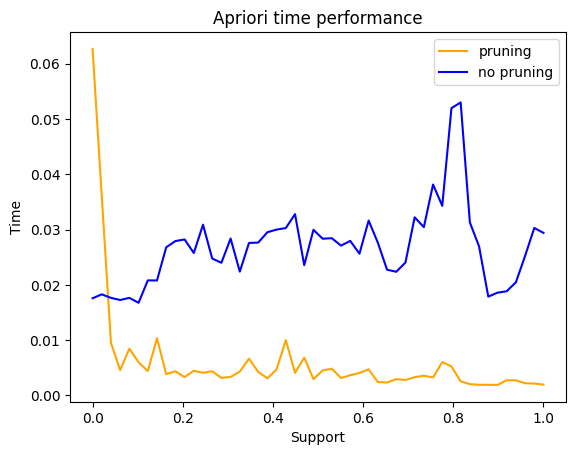

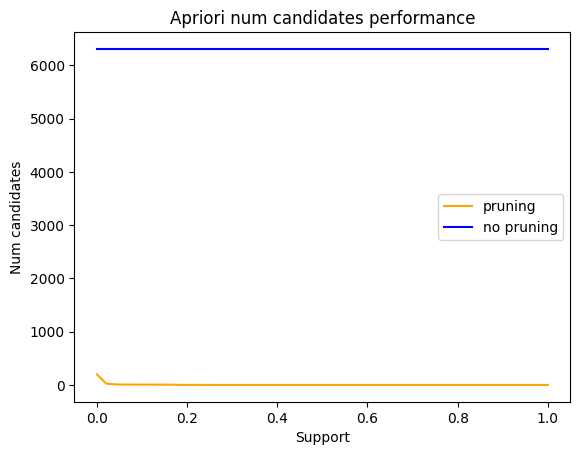

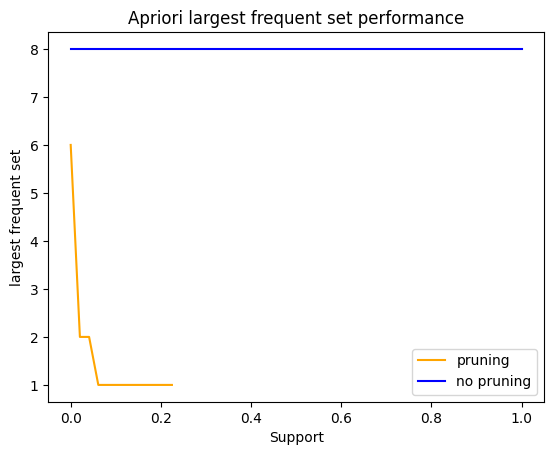

In [181]:
import time as t
import matplotlib.pyplot as plt
import numpy as np
import sys

experimantal_supports = np.linspace(0.000001,1,50)
time_pruning = []
time_no_pruning = []

candidates_pruning = []
candidates_no_pruning = []

largest_frequent_set_pruning = []
largest_frequent_set_no_pruning = []

for support in experimantal_supports:
    start = t.time()
    frequent_itemsets = apriori(df, min_support=support, use_colnames=True)
    end = t.time()
    candidates_pruning.append(len(frequent_itemsets))
    largest_frequent_set_pruning.append(frequent_itemsets['itemsets'].apply(len).max())
    time_pruning.append(end - start)
    
for support in experimantal_supports:
    start = t.time()
    frequent_itemsets = apriori(df, min_support=sys.float_info.epsilon, use_colnames=True)
    end = t.time()
    d = len(df.columns)
    candidates_no_pruning.append(3**d - 2**d +1)
    largest_frequent_set_no_pruning.append(d)
    time_no_pruning.append(end - start)
    
plt.plot(experimantal_supports, time_pruning, color='orange', label= 'pruning')
plt.plot(experimantal_supports, time_no_pruning, color='blue', label = 'no pruning')
plt.xlabel('Support')
plt.ylabel('Time')
plt.legend()
plt.title('Apriori time performance')
plt.show()

plt.plot(experimantal_supports, candidates_pruning, color='orange', label= 'pruning')
plt.plot(experimantal_supports, candidates_no_pruning, color='blue', label= 'no pruning')
plt.xlabel('Support')
plt.ylabel('Num candidates')
plt.title('Apriori num candidates performance')
plt.legend()
plt.show()

plt.plot(experimantal_supports, largest_frequent_set_pruning, color='orange', label= 'pruning')
plt.plot(experimantal_supports, largest_frequent_set_no_pruning, color='blue', label= 'no pruning')
plt.xlabel('Support')
plt.ylabel('largest frequent set')
plt.legend()
plt.title('Apriori largest frequent set performance')
plt.show()